In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
import sklearn as sk # for machine learning
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score


In [2]:
path=r"D:\\ML-SVM\\pulsar_stars.csv"
df=pd.read_csv(path)
df.columns = df.columns.str.strip()
df.columns = ['IP Mean', 'IP Sd', 'IP Kurtosis', 'IP Skewness', 
              'DM-SNR Mean', 'DM-SNR Sd', 'DM-SNR Kurtosis', 'DM-SNR Skewness', 'target_class']
print(df.head())
print(df.shape)
print(df.info())

print(df['target_class'].value_counts())
print(df.isnull().sum())
print(df.describe())

      IP Mean      IP Sd  IP Kurtosis  IP Skewness  DM-SNR Mean  DM-SNR Sd  \
0  140.562500  55.683782    -0.234571    -0.699648     3.199833  19.110426   
1  102.507812  58.882430     0.465318    -0.515088     1.677258  14.860146   
2  103.015625  39.341649     0.323328     1.051164     3.121237  21.744669   
3  136.750000  57.178449    -0.068415    -0.636238     3.642977  20.959280   
4   88.726562  40.672225     0.600866     1.123492     1.178930  11.468720   

   DM-SNR Kurtosis  DM-SNR Skewness  target_class  
0         7.975532        74.242225             0  
1        10.576487       127.393580             0  
2         7.735822        63.171909             0  
3         6.896499        53.593661             0  
4        14.269573       252.567306             0  
(17898, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   IP 

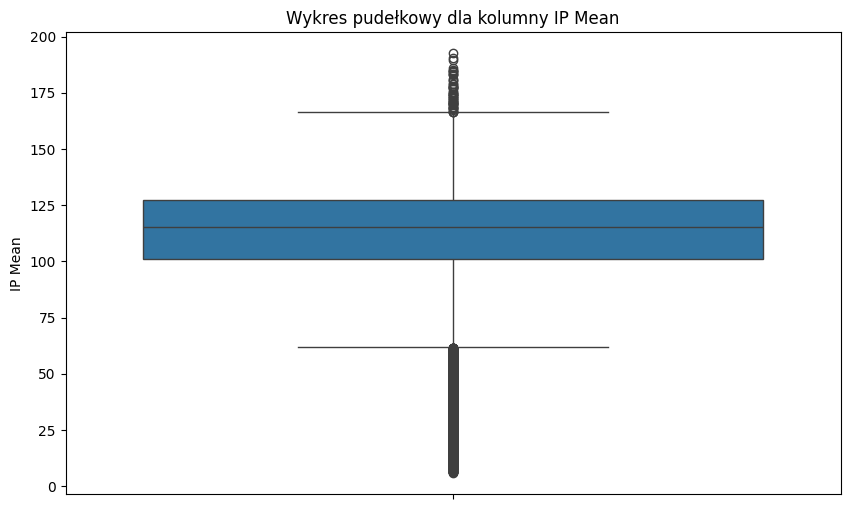

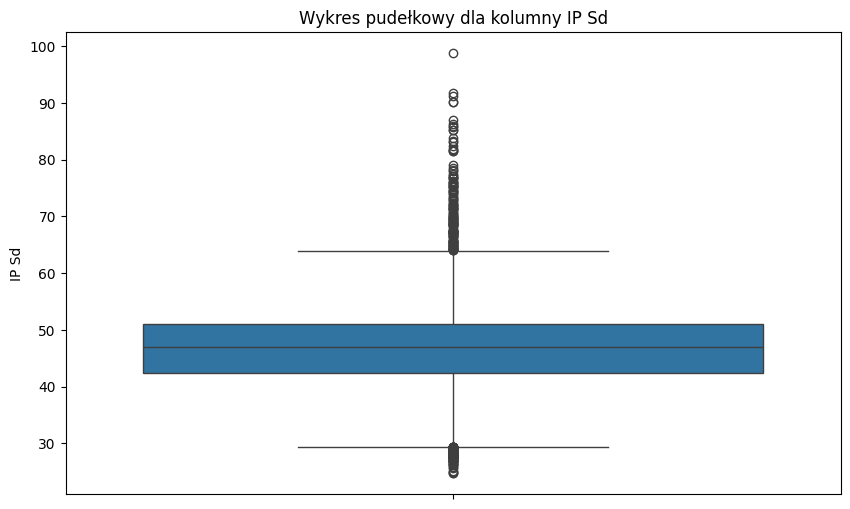

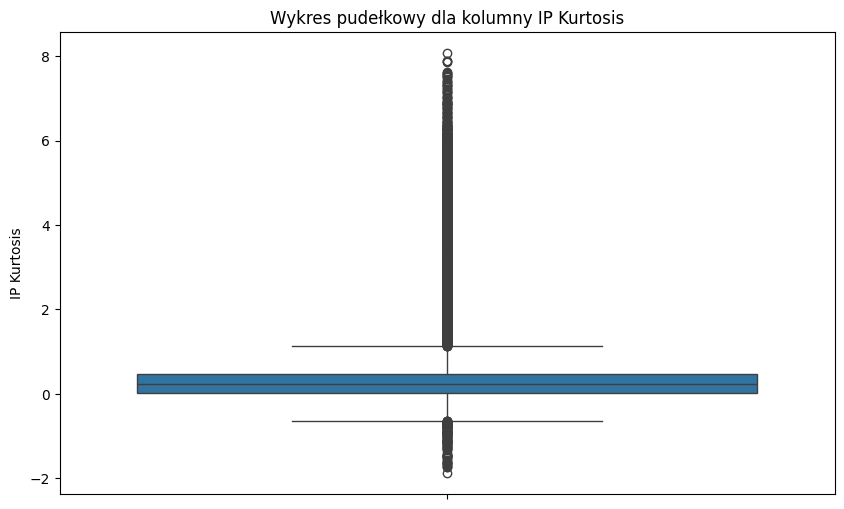

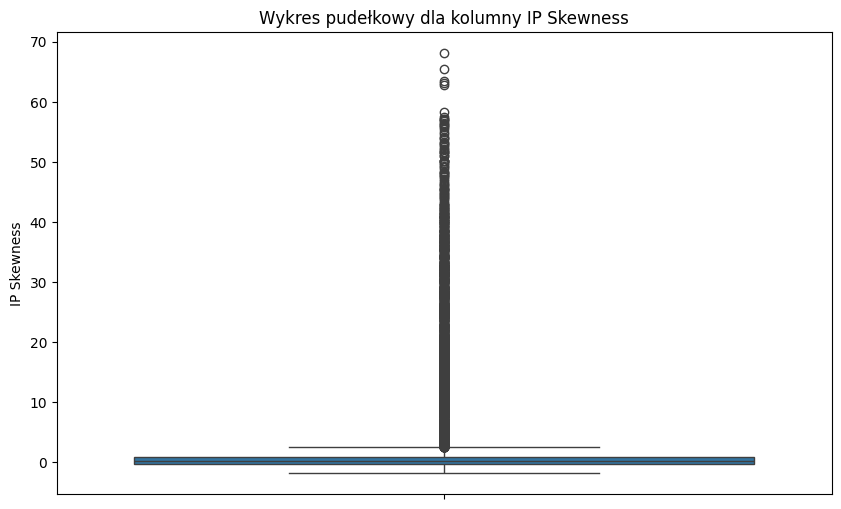

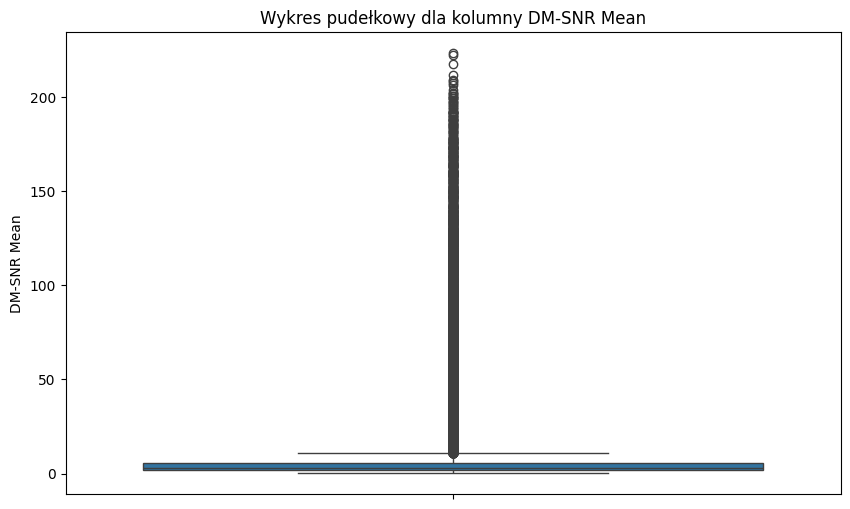

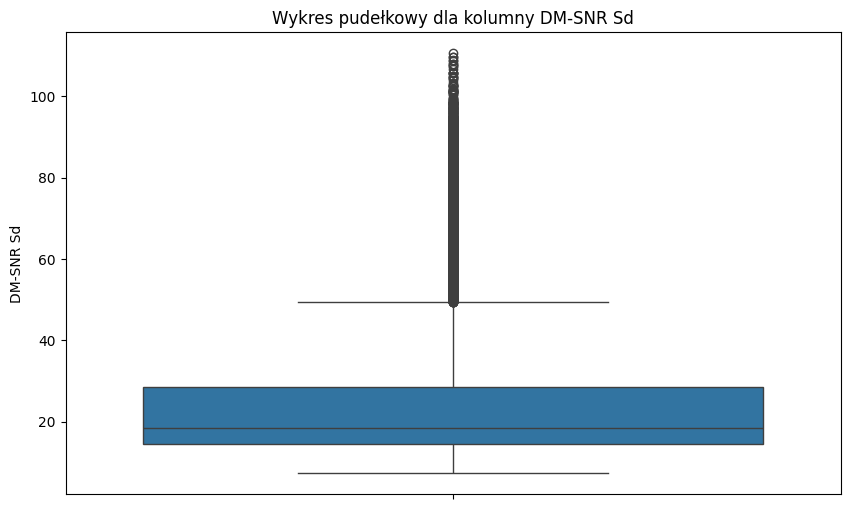

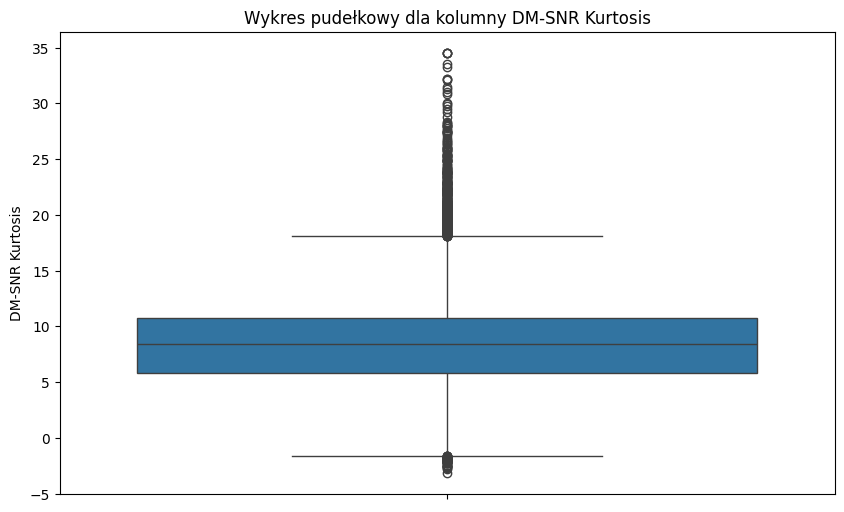

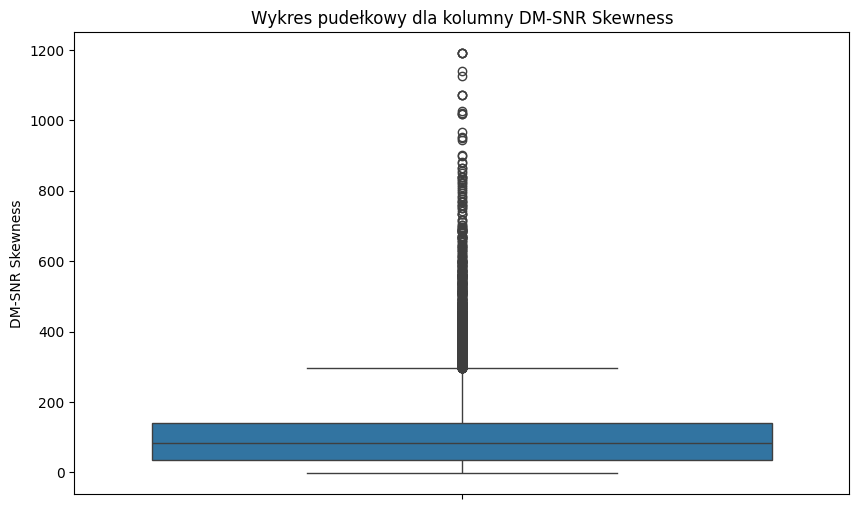

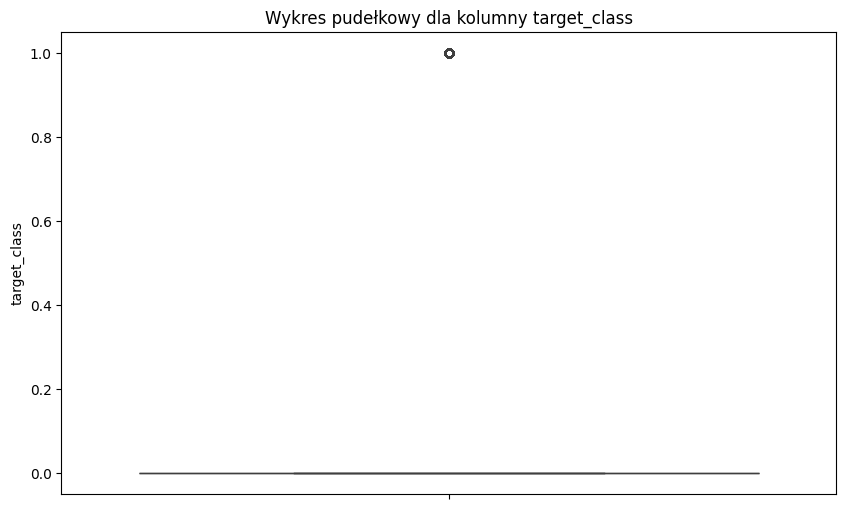

In [3]:

for kolumna in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df[kolumna])  # Zmień 'kolumna' na nazwę swojej kolumny
    plt.title(f'Wykres pudełkowy dla kolumny {kolumna}')
    plt.show()



Text(0, 0.5, 'Number of pulsar stars')

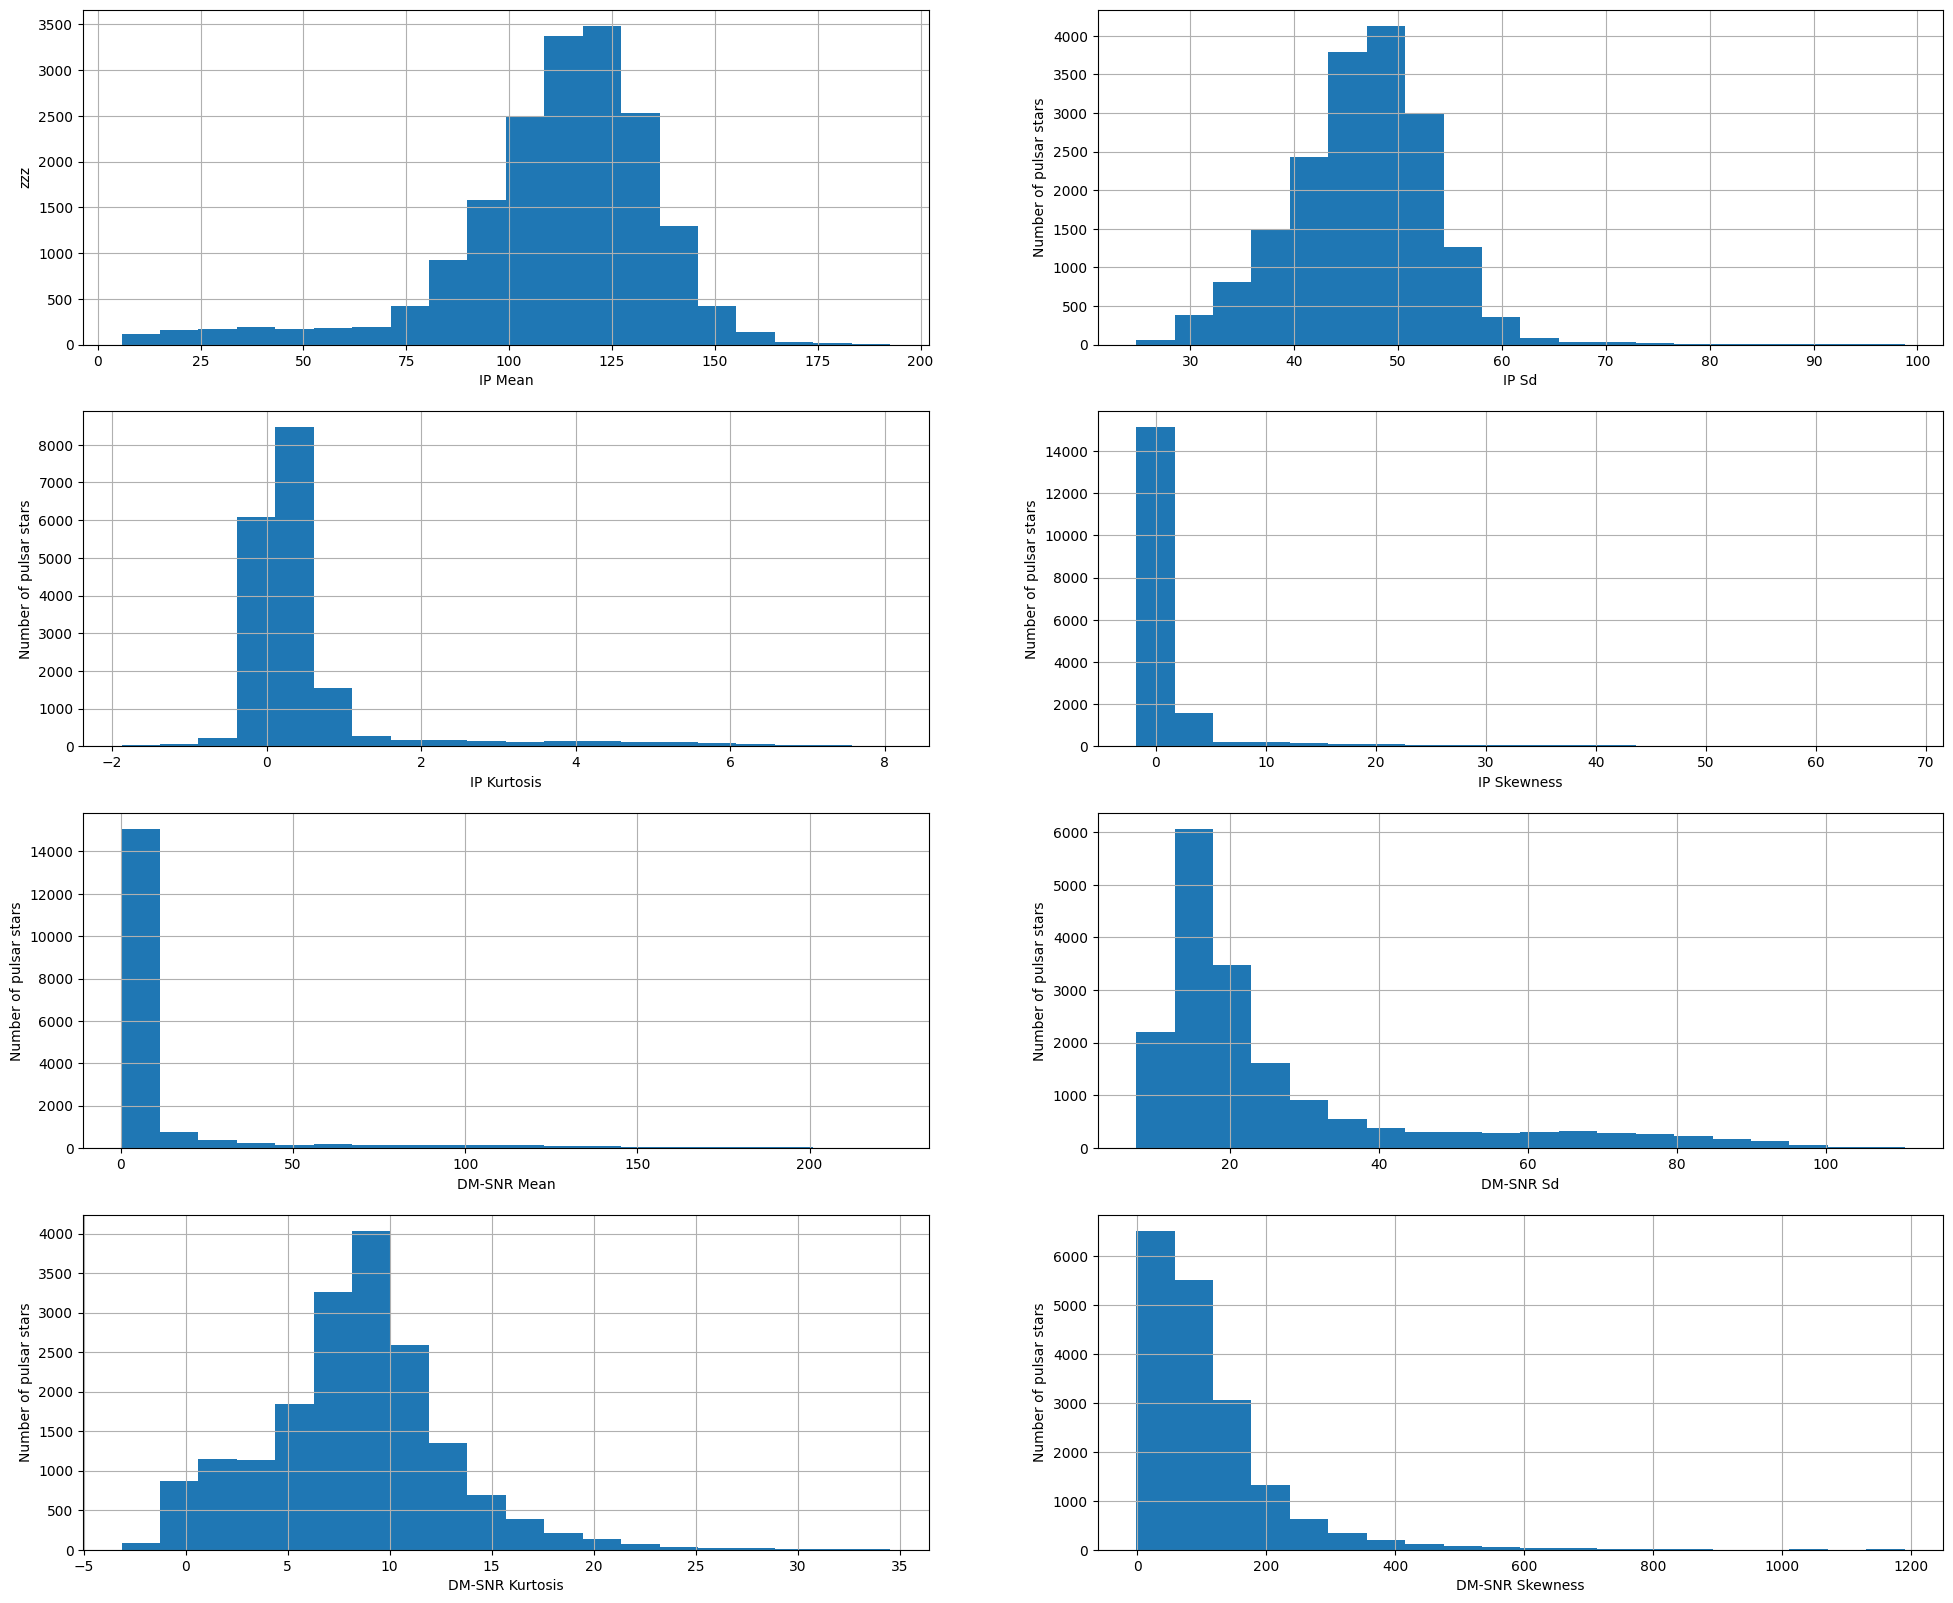

In [4]:



plt.figure(figsize=(24,20))


plt.subplot(4, 2, 1)
fig = df['IP Mean'].hist(bins=20)
fig.set_xlabel('IP Mean')
fig.set_ylabel('zzz')


plt.subplot(4, 2, 2)
fig = df['IP Sd'].hist(bins=20)
fig.set_xlabel('IP Sd')
fig.set_ylabel('Number of pulsar stars')


plt.subplot(4, 2, 3)
fig = df['IP Kurtosis'].hist(bins=20)
fig.set_xlabel('IP Kurtosis')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 4)
fig = df['IP Skewness'].hist(bins=20)
fig.set_xlabel('IP Skewness')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 5)
fig = df['DM-SNR Mean'].hist(bins=20)
fig.set_xlabel('DM-SNR Mean')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 6)
fig = df['DM-SNR Sd'].hist(bins=20)
fig.set_xlabel('DM-SNR Sd')
fig.set_ylabel('Number of pulsar stars')



plt.subplot(4, 2, 7)
fig = df['DM-SNR Kurtosis'].hist(bins=20)
fig.set_xlabel('DM-SNR Kurtosis')
fig.set_ylabel('Number of pulsar stars')


plt.subplot(4, 2, 8)
fig = df['DM-SNR Skewness'].hist(bins=20)
fig.set_xlabel('DM-SNR Skewness')
fig.set_ylabel('Number of pulsar stars')

In [5]:
X=df.drop('target_class',axis=1)
y=df['target_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(14318, 8)
(3580, 8)
(14318,)
(3580,)


In [6]:
model=SVC()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(y_pred)

[0 0 0 ... 0 0 1]


In [7]:
clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))
clf.fit(X_train, y_train)
print(clf.score(X_test, y_test))


0.979608938547486


In [8]:
from sklearn.pipeline import Pipeline


param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 1],
    'svc__kernel': ['linear', 'rbf'],
    'svc__class_weight':['balanced']
}

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

grid = GridSearchCV(pipeline, param_grid, cv=2, scoring='accuracy')

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)
print(grid.score(X_test, y_test))

{'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
0.9736695069143735
0.9762569832402235


target_class
0    3259
1     321
Name: count, dtype: int64
[[3201   58]
 [  27  294]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3259
           1       0.84      0.92      0.87       321

    accuracy                           0.98      3580
   macro avg       0.91      0.95      0.93      3580
weighted avg       0.98      0.98      0.98      3580



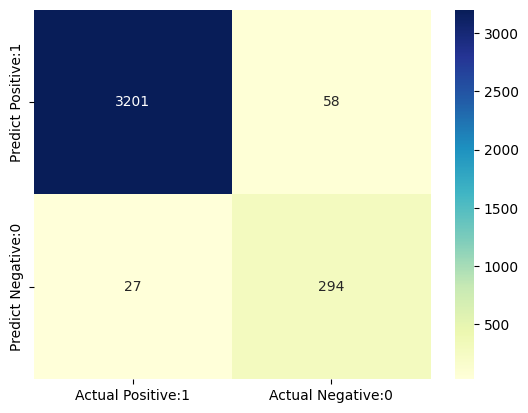

In [9]:
from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

y_pred = grid.predict(X_test)

print(y_test.value_counts())    



cm = confusion_matrix(y_test, y_pred)

print(cm)

cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')



print(classification_report(y_test, y_pred))



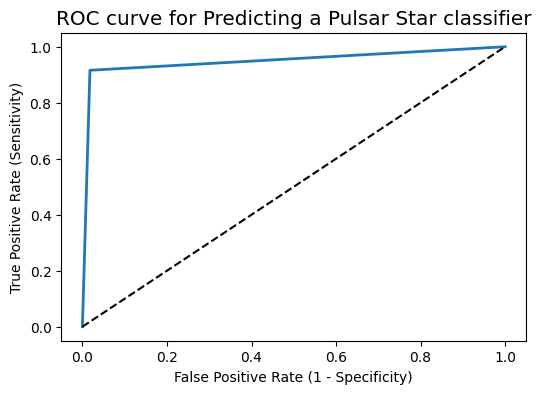

ROC AUC : 0.9490


In [10]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12

plt.title('ROC curve for Predicting a Pulsar Star classifier')

plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()

from sklearn.metrics import roc_auc_score

ROC_AUC = roc_auc_score(y_test, y_pred)

print('ROC AUC : {:.4f}'.format(ROC_AUC))

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 1],
    'svc__kernel': ['linear', 'rbf'],
    'svc__class_weight': ['balanced']
}

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

stratified_kfold = StratifiedKFold(n_splits=5)  

grid = GridSearchCV(pipeline, param_grid, cv=stratified_kfold, scoring='accuracy')

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)
print(grid.score(X_test, y_test))


{'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
0.9744381455167744
0.9762569832402235
